In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style(style='whitegrid')
sns.set_context(context='notebook')
plt.rcParams['figure.figsize'] = (11, 9.4)

titanic_df = sns.load_dataset('titanic')
titanic_df.dropna(inplace=True)
titanic_df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


In [2]:
titanic_df.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object


In [3]:
titanic_df['sex'].unique()

array(['female', 'male'], dtype=object)

In [4]:
titanic_df['embarked'].unique()

array(['C', 'S', 'Q'], dtype=object)

In [5]:
titanic_df['class'].unique()

['First', 'Third', 'Second']
Categories (3, object): ['First', 'Second', 'Third']

In [6]:
titanic_df['who'].unique()

array(['woman', 'man', 'child'], dtype=object)

In [7]:
titanic_df['deck'].unique()

['C', 'E', 'G', 'D', 'A', 'B', 'F']
Categories (7, object): ['A', 'B', 'C', 'D', 'E', 'F', 'G']

In [8]:
titanic_df['embark_town'].unique()

array(['Cherbourg', 'Southampton', 'Queenstown'], dtype=object)

In [9]:
titanic_df['alive'].unique()

array(['yes', 'no'], dtype=object)

# LABEL ENCODING

In [10]:
df_encoded = titanic_df.copy()

In [11]:
df_encoded['numeric_sex'] = df_encoded['sex'].map({'female':0,'male':1})
df_encoded

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,numeric_sex
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,0
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True,1
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False,0
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False,0
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True,1
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False,0
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,0


In [12]:
df_encoded['numeric_alive'] = df_encoded['alive'].map({'no':0,'yes':1})
df_encoded

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,numeric_sex,numeric_alive
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,0,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,0,1
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True,1,0
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False,0,1
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False,0,1
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True,1,0
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False,0,1
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,0,1


In [13]:
df_encoded = pd.get_dummies(df_encoded,columns=['embarked','class','who','deck','embark_town'],prefix='numeric',dtype=int)
df_encoded

,survived,pclass,sex,age,sibsp,parch,fare,adult_male,alive,alone,...,numeric_A,numeric_B,numeric_C,numeric_D,numeric_E,numeric_F,numeric_G,numeric_Cherbourg,numeric_Queenstown,numeric_Southampton
1,1,1,female,38.0,1,0,71.2833,False,yes,False,...,0,0,1,0,0,0,0,1,0,0
3,1,1,female,35.0,1,0,53.1000,False,yes,False,...,0,0,1,0,0,0,0,0,0,1
6,0,1,male,54.0,0,0,51.8625,True,no,True,...,0,0,0,0,1,0,0,0,0,1
10,1,3,female,4.0,1,1,16.7000,False,yes,False,...,0,0,0,0,0,0,1,0,0,1
11,1,1,female,58.0,0,0,26.5500,False,yes,True,...,0,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,False,yes,False,...,0,0,0,1,0,0,0,0,0,1
872,0,1,male,33.0,0,0,5.0000,True,no,True,...,0,1,0,0,0,0,0,0,0,1
879,1,1,female,56.0,0,1,83.1583,False,yes,False,...,0,0,1,0,0,0,0,1,0,0
887,1,1,female,19.0,0,0,30.0000,False,yes,True,...,0,1,0,0,0,0,0,0,0,1


<Axes: >

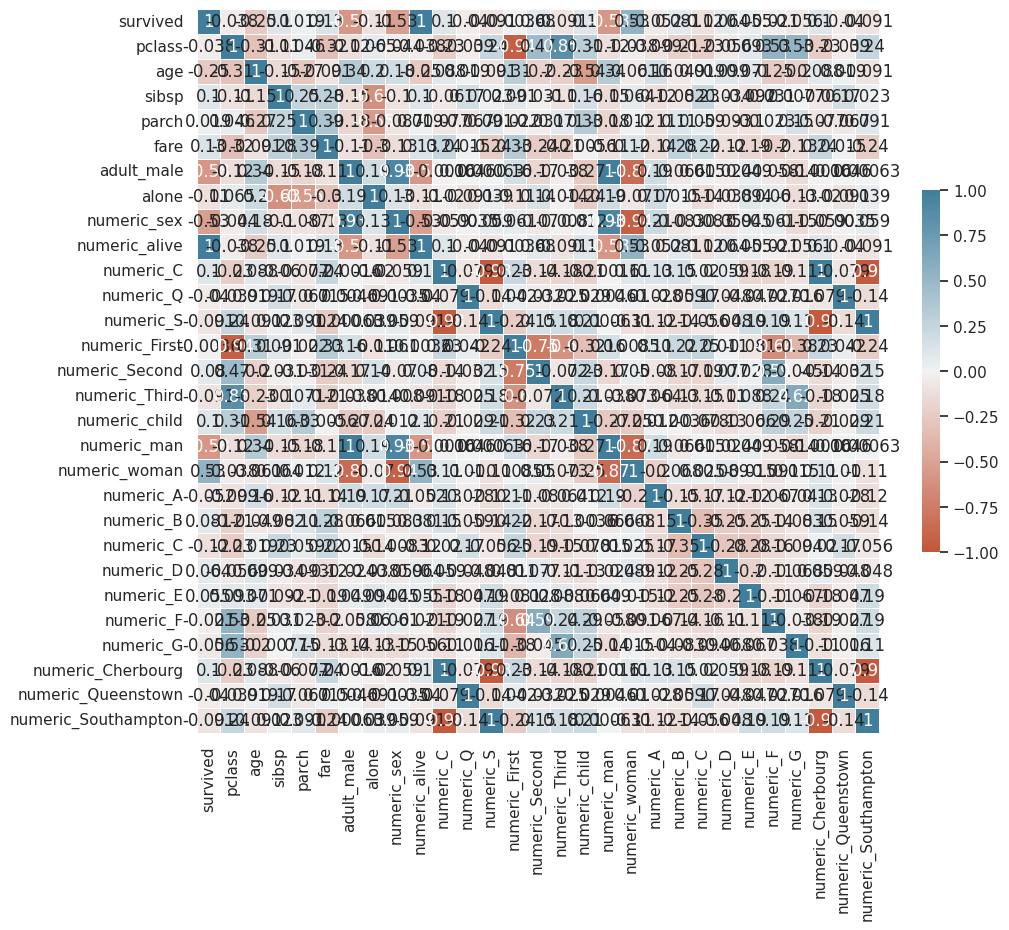

In [14]:
sns.heatmap(
    data=df_encoded.corr(numeric_only=True),
    cmap=sns.diverging_palette(20,230,as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'shrink':0.5},
    annot=True
)

<Axes: >

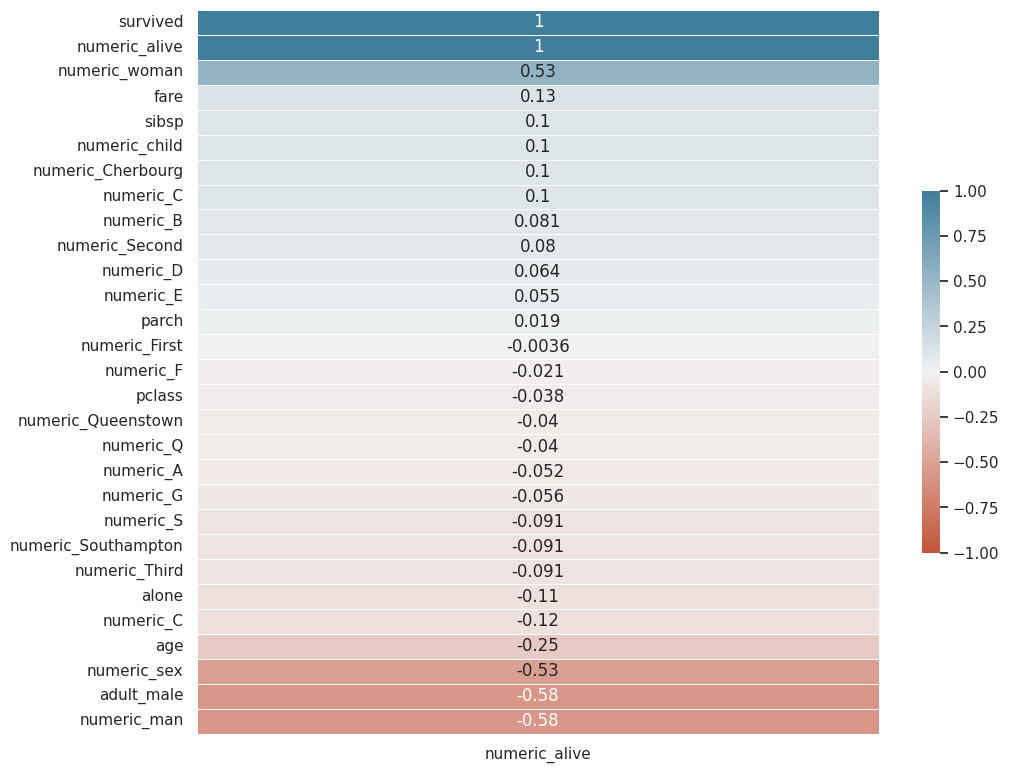

In [15]:
corr_matrix = df_encoded.corr(numeric_only=True)
corr_age = corr_matrix[['numeric_alive']].sort_values(by='numeric_alive',ascending=False)
sns.heatmap(
    data=corr_age,
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'shrink': 0.5},
    annot=True
)